<a href="https://colab.research.google.com/github/Hope-Alemayehu/causal-inference-medical-treatment/blob/main/causal_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causal Inference vs Machine Learning in Medical Treatment Data

## The Problem This Project Solves

Standard machine learning models learn correlations from data.
In medicine, this is dangerous.

**Example:** Doctors tend to give treatments to less severely ill patients.
Those patients also recover faster not necessarily because of the treatment,
but because they were healthier to begin with.

A naive ML model sees: *treated patients recover more* → concludes:
*treatment is very effective.*

A causal model asks: *if we forced everyone to receive treatment,
regardless of severity — what would actually happen?*

These are fundamentally different questions. This project demonstrates
the difference using simulated patient data and the DoWhy causal inference library.

## What You'll See
- An ML model that overestimates treatment effect by **3x**
- A causal model (DoWhy) that recovers close to the true effect
- Why the difference matters for real medical AI systems

## Tools Used
- `DoWhy` — Microsoft's causal inference library
- `scikit-learn` — for the naive ML baseline
- `pandas / numpy` — data simulation
- `matplotlib` — visualization

In [ ]:
!pip install dowhy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import dowhy
from dowhy import CausalModel


## Generating Patient Data

We simulate 1,000 patients with four variables:

| Variable | Description |
|---|---|
| `age` | Patient age (20–80) |
| `severity` | How sick they are (0 = mild, 1 = severe) |
| `treatment` | Did they receive the drug? (0 = no, 1 = yes) |
| `recovery` | Did they recover? (0 = no, 1 = yes) |




In [ ]:
# So we get the same random data every time
np.random.seed(42)

n_patients = 1000

### The Hidden Bias We Deliberately Bake In

Doctors give treatment preferentially to **less severe** patients:
- Severe patient chance of treatment: **30%**
- Mild patient chance of treatment: **80%**

This mirrors real clinical behavior — doctors often reserve
aggressive treatments for patients they believe can tolerate them,
or use milder interventions first on severe cases.

### The Ground Truth We Control

Because this is simulated data, we know the real treatment effect exactly:

```python
recovery_prob = 0.5 - 0.3 * severity - 0.2 * (age/80) + 0.1 * treatment
```

**Treatment contributes exactly 0.10 to recovery probability.**
Age and severity contribute the rest. We will test whether each
model can recover this true value.


In [ ]:
# 1. AGE: patients between 20 and 80 years old
age = np.random.randint(20, 80, n_patients)

# 2. SEVERITY: sicker if older (age adds risk)
severity = (age > 50).astype(int) + np.random.randint(0, 2, n_patients)
severity = np.clip(severity, 0, 1)  # keep it 0 or 1

# 3. TREATMENT: doctors prefer giving it to less severe patients
treatment_prob = 0.8 - 0.5 * severity
treatment = np.random.binomial(1, treatment_prob, n_patients)

# 4. RECOVERY: the ground truth we control
recovery_prob = (
    0.5              # base recovery chance
    - 0.3 * severity # severity hurts recovery
    - 0.2 * (age/80) # age hurts recovery
    + 0.1 * treatment # treatment helps — but only a little
)
recovery = np.random.binomial(1, recovery_prob, n_patients)



In [ ]:
# Put it all in a dataframe
df = pd.DataFrame({
    'age': age,
    'severity': severity,
    'treatment': treatment,
    'recovery': recovery
})

df.head(10)


,age,severity,treatment,recovery
0,58,1,0,0
1,71,1,1,0
2,48,0,1,1
3,34,1,0,0
4,62,1,1,0
5,27,1,0,0
6,40,1,0,0
7,58,1,0,0
8,77,1,1,0
9,38,1,0,0


In [ ]:
print("Dataset shape:", df.shape)
print("\nFirst look:")
print(df.describe())

print("\n--- The Bias We Hid ---")
print("Recovery rate for TREATED patients:",
      df[df['treatment']==1]['recovery'].mean().round(3))
print("Recovery rate for UNTREATED patients:",
      df[df['treatment']==0]['recovery'].mean().round(3))
print("Naive difference (what ML will see):",
      (df[df['treatment']==1]['recovery'].mean() -
       df[df['treatment']==0]['recovery'].mean()).round(3))
print("\nReal treatment effect we programmed: 0.10")

Dataset shape: (1000, 4)

First look:
               age     severity    treatment    recovery
count  1000.000000  1000.000000  1000.000000  1000.00000
mean     50.200000     0.740000     0.433000     0.19200
std      17.372905     0.438854     0.495739     0.39407
min      20.000000     0.000000     0.000000     0.00000
25%      36.000000     0.000000     0.000000     0.00000
50%      51.000000     1.000000     0.000000     0.00000
75%      66.000000     1.000000     1.000000     0.00000
max      79.000000     1.000000     1.000000     1.00000

--- The Bias We Hid ---
Recovery rate for TREATED patients: 0.321
Recovery rate for UNTREATED patients: 0.093
Naive difference (what ML will see): 0.228

Real treatment effect we programmed: 0.10


What ML will see:     0.228  (128% bigger than reality)
Real effect:          0.10

The ML model is going to think the drug is more than twice as effective as it actually is. That's not a small rounding error — that's a fundamentally wrong conclusion that in a real hospital could mean:
. Overfunding an overrated drug
- Giving false confidence to doctors
- Missing that severely ill patients aren't actually benefiting much

And the cause is entirely that one line: treatment_prob = 0.8 - 0.5 * severity. The drug looks powerful because healthy people got it and healthy people recovered. Nothing more.

In [ ]:
# Prepare data
X = df[['age', 'severity', 'treatment']]
y = df['recovery']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
ml_model = LogisticRegression()
ml_model.fit(X_scaled, y)

# Extract what the model thinks each variable does
feature_names = ['age', 'severity', 'treatment']
coefficients = ml_model.coef_[0]

print("--- What the ML Model Learned ---")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.3f}")

print(f"\nML model's implied treatment effect: {coefficients[2]:.3f}")
print(f"Real treatment effect we programmed: 0.10")

--- What the ML Model Learned ---
age: -0.416
severity: -0.715
treatment: 0.301

ML model's implied treatment effect: 0.301
Real treatment effect we programmed: 0.10


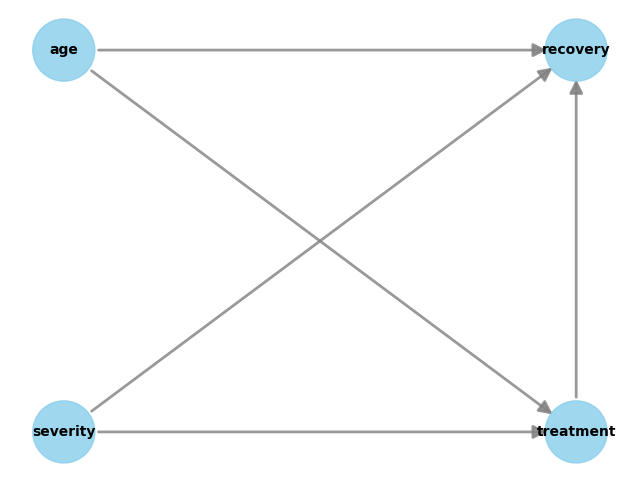

In [ ]:
# Step 1: MODEL
# We declare what we believe causes what
# This is the DAG — we're telling DoWhy the causal structure
model = CausalModel(
    data=df,
    treatment='treatment',
    outcome='recovery',
    common_causes=['age', 'severity']  # confounders
)

# Visualize the graph DoWhy built
model.view_model()

In [ ]:
# Step 2: IDENTIFY
# DoWhy figures out mathematically whether the causal effect
# can be estimated from this data given the graph
identified_estimand = model.identify_effect(
    proceed_when_unidentifiable=True
)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                
────────────(E[recovery|severity,age])
d[treatment]                          
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→recovery then P(recovery|treatment,severity,age,U) = P(recovery|treatment,severity,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                
────────────(E[recovery|severity,age])
d[treatment]                          
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→recovery then P(recovery|treatment,severity,age,U) = P(recovery|treatment,severity,age)



In [ ]:
# Step 3: ESTIMATE
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print("--- Causal Model Results ---")
print(f"Causal estimate of treatment effect: {estimate.value:.3f}")
print(f"ML model's estimate:                 0.301")
print(f"Real effect we programmed:           0.100")

--- Causal Model Results ---
Causal estimate of treatment effect: 0.070
ML model's estimate:                 0.301
Real effect we programmed:           0.100


In [ ]:
# Step 4: REFUTE
# Attack 1: Replace treatment with random data
# If your effect disappears, it was real
# If it stays the same, something is wrong
refute_random = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)
print("--- Refutation Test ---")
print(refute_random)

--- Refutation Test ---
Refute: Add a random common cause
Estimated effect:0.07045830135954895
New effect:0.07051000035848913
p value:0.9199999999999999



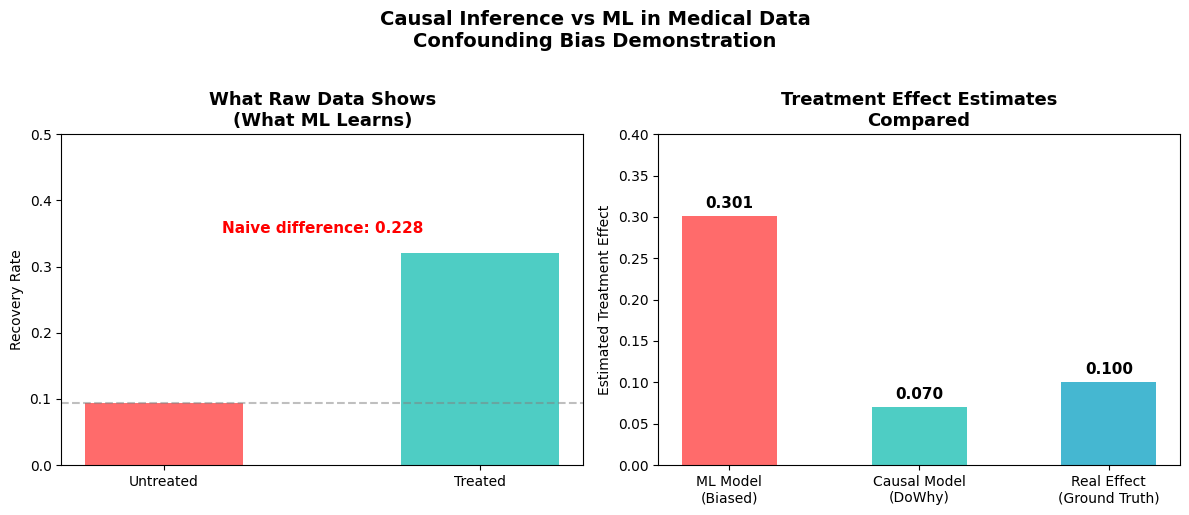


Plot saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: what the data naively shows
ax1 = axes[0]
treated = df[df['treatment']==1]['recovery'].mean()
untreated = df[df['treatment']==0]['recovery'].mean()
naive = treated - untreated

bars1 = ax1.bar(
    ['Untreated', 'Treated'],
    [untreated, treated],
    color=['#ff6b6b', '#4ecdc4'],
    width=0.5
)
ax1.axhline(y=untreated, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('What Raw Data Shows\n(What ML Learns)',
               fontsize=13, fontweight='bold')
ax1.set_ylabel('Recovery Rate')
ax1.set_ylim(0, 0.5)
ax1.text(0.5, 0.35,
         f'Naive difference: {naive:.3f}',
         ha='center', fontsize=11,
         color='red', fontweight='bold')

# Right plot: the three estimates side by side
ax2 = axes[1]
methods = ['ML Model\n(Biased)', 'Causal Model\n(DoWhy)', 'Real Effect\n(Ground Truth)']
values = [0.301, estimate.value, 0.100]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

bars2 = ax2.bar(methods, values, color=colors, width=0.5)
ax2.set_title('Treatment Effect Estimates\nCompared',
               fontsize=13, fontweight='bold')
ax2.set_ylabel('Estimated Treatment Effect')
ax2.set_ylim(0, 0.4)

# Add value labels on bars
for bar, val in zip(bars2, values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.suptitle('Causal Inference vs ML in Medical Data\n'
             'Confounding Bias Demonstration',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('causal_vs_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved!")
